# Rozpoznávání emocí v řeči: SVM vs. konvoluční neuronová síť

Autor: Daniel Senčišin

**Dataset:** [CREMA-D – Crowd-sourced Emotional Multimodal Actors Dataset](https://www.kaggle.com/datasets/ejlok1/cremad)
(audio-only část, 7 442 nahrávek)

**Metadata o hercích a lidská hodnocení:** [oficiální repozitář CREMA-D](https://github.com/CheyneyComputerScience/CREMA-D)

Jak spustit: Run All

---

## 0. Volba datasetu: proč nakonec CREMA-D a ne RAVDESS

Úlohu jsem původně postavil na datasetu **RAVDESS**, který se v této oblasti používá nejčastěji. Při přípravě
dat jsem ale narazil na jeho limity a nakonec jsem přešel na **CREMA-D**. Protože to ovlivňuje všechny výsledky níže, vysvětlím ho hned na začátku.

| | RAVDESS | **CREMA-D** (použitý) |
|---|---|---|
| nahrávek | 1 440 | **7 442** |
| **herců** | 24 | **91** (48 mužů / 43 žen) |
| různých vět | 2 | **12** |
| tříd (emocí) | 8 (včetně *calm*, *surprised*) | 6  |
| audio | 48 kHz, 16 bit | 16 kHz, mono, 16 bit |
| metadata o mluvčím | jen pohlaví | **věk 20–74, pohlaví, rasa, etnicita** |
| lidské hodnocení nahrávek | není součástí | **je, pro všech 7 442 nahrávek** |
| vyváženost tříd | perfektní (kromě *neutral*) | mírná (*neutral* 1 087 vs. 1 271) |

### Tři důvody, proč CREMA-D

**1. Rozhoduje počet herců, ne počet nahrávek.** Hlavním rizikem přeučení v této úloze je identita mluvčího –
model se snadno naučí rozpoznávat herce místo emoce. Proto dělím data podle herců (kapitola 5). S 24 herci
RAVDESS mi ale v testovací sadě zbývá jen ~5 lidí, takže rozdíl 0,52 vs. 0,55 macro F1 nemá výpovědní hodnotu:
kolísá podle toho, kteří herci do testu zrovna padnou. S 91 herci mám v testu 18 mluvčích a čísla se stávají
obhajitelnými. Dvanáct různých vět místo dvou navíc znemožňuje, aby se model chytil konkrétní věty.

**2. Objem dat kvůli hlavní otázce práce – SVM vs. CNN.** Na 1 440 vzorcích tuhle otázku nelze moc
rozhodnout: konvoluční síť má i v malé konfiguraci srovnatelný počet parametrů, jako má dataset vzorků, takže
výsledek by vypovídal spíš o nastavení regularizace než o architektuře. Se 7 442 vzorky srovnání smysl dává.

**3. Lidský baseline.** CREMA-D obsahuje crowd-sourced hodnocení všech nahrávek – u každé je zaznamenáno, jakou
emoci v ní slyšeli lidští hodnotitelé. Lidé, kteří měli k dispozici **jen zvuk**, určili zamýšlenou emoci
správně ve **41,6 %** případů (spočítáno v kapitole 3.5). To mi umožní vlastní výsledky zasadit do kontextu. U RAVDESS taková referenční hodnota k dispozici není a je to podle mě největší přidaná hodnota téhle volby.

### Co jsem tím obětoval

- **Dvě třídy** – *calm* a *surprised*. `calm` není základní emoce, je to specifikum RAVDESS a od `neutral` se
  akusticky odlišuje spíš definičně než měřitelně. Šest základních emocí by měla být standardní volba.
- **Faktor intenzity.** RAVDESS má intenzitu vyváženou 50/50 (normal/strong), CREMA-D má u 6 077 ze 7 442
  nahrávek intenzitu neurčenou (`XX`). Jako proměnnou do analýzy ji tedy
  prakticky ztrácím – nahrazuji ji ale mírou shody lidských hodnotitelů - ta je dostupná i u všech.
- **Kvalitu záznamu** – 16 kHz místo 48 kHz. Pro řeč je to dostatečné a hlavně mají všechny nahrávky stejné parametry, takže nehrozí, že by model rozlišoval nahrávací podmínky místo emoce.

### Proč datasety neslučuji

Nabízí se „vzít oba a mít ještě víc dat“. Nedělám to ze dvou důvodů:

1. **Neshodují se množiny emocí.** *calm* a *surprised* by existovaly jen v jednom z korpusů, takže by se model
   naučil, že „studiový zvuk RAVDESS ⇒ může to být calm“.
2. **Liší se vzorkovací frekvence** (48 vs. 16 kHz). Po převzorkování na společnou hodnotu má RAVDESS obsah
   i v horním pásmu spektra a CREMA-D tam má prázdno – pro konvoluční síť je to dokonalý identifikátor korpusu.

---

## 1. Zadání

**Typ úlohy:** učení s učitelem (supervised learning), konkrétně **vícetřídová klasifikace** (multi-class
classification) do 6 tříd.

**Popis problému:** Na vstupu je krátká zvuková nahrávka (herec vysloví jednu z dvanácti obsahově neutrálních
vět v dané emoci), na výstupu chceme predikovat **emoci** mluvčího. Jde tedy o úlohu *Speech Emotion
Recognition (SER)*. Zvuk sám o sobě není tabulkový vstup – musíme z něj nejdřív vytvořit číselnou reprezentaci
(příznaky/features).

**Proč:**
- věty jsou záměrně obsahově neutrální („Don't forget a jacket“), takže se model **nemůže opřít o obsah řeči**,
  jen o způsob přednesu (prozodii, energii, barvu hlasu),
- emoce jako *sad* vs. *neutral* nebo *fearful* vs. *sad* jsou akusticky velmi podobné – ostatně i lidští
  hodnotitelé určí správnou emoci jen ze zvuku pouze ve 41,6 % případů (kapitola 3.5),
- projev je silně **závislý na mluvčím** – model se snadno naučí rozpoznávat herce místo emoce.
  Proto níže dělíme data **podle herců**, ne náhodně (jinak by výsledky byly opticky mnohem lepší, ale nepravdivé).

**Postup:**
1. načtení dat, parsování metadat z názvů souborů, připojení demografie herců a lidských hodnocení, čištění,
2. popisná statistika a vizualizace,
3. extrakce příznaků (log-mel spektrogram → 2D vstup pro CNN; statistiky MFCC → vektor pro SVM),
4. **baseline**: `DummyClassifier` + `SVC` s výchozími parametry,
5. **vlastní/lepší modely**: SVM s laděním hyperparametrů (GridSearch + skupinová CV) a CNN,
6. porovnání metrik, časů trénování a inference – **včetně srovnání s lidskými hodnotiteli**,
7. analýza problémových vzorků, rozpad úspěšnosti podle skupin mluvčích, závěr.

**Hlavní metrika: macro F1** – průměr F1 přes třídy bez ohledu na jejich velikost. Volím ji ze dvou důvodů:
třída *neutral* je mírně menší než ostatní (1 087 vs. 1 271) a hlavně se jednotlivé emoce **výrazně liší
obtížností** – accuracy by dovolila, aby dobrý výsledek na snadném *angry* zamaskoval selhání na obtížném
*sad*. Accuracy reportuji jako doplňkovou (je intuitivnější a snadno se interpretuje ústně).

---
## 2. Příprava prostředí a načtení dat

In [1]:
# Instalace závislostí. V Google Colabu jsou librosa i kagglehub předinstalované,
# proto je řádek zakomentovaný; v lokálním prostředí ho stačí odkomentovat.
#!pip -q install librosa kagglehub

In [2]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import soundfile as sf
import librosa
import librosa.display

from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("librosa:", librosa.__version__, " TensorFlow:", tf.__version__)

librosa: 0.11.0  TensorFlow: 2.21.0


### 2.1 Stažení dat

Potřebuji tři věci:

1. **audio** – `kagglehub` stáhne 7 442 WAV souborů z Kaggle (451 MB). Jsou-li data dostupná
   lokálně nebo na Google Disku, stačí vyplnit `DATA_DIR` a stahování se přeskočí.
2. **demografii herců** (`VideoDemographics.csv`, 4 kB) – věk, pohlaví, rasa a etnicita všech 91 herců.
   Není součástí Kaggle verze, tahám ji přímo z oficiálního repozitáře CREMA-D.
3. **lidská hodnocení** (`processedResults/summaryTable.csv`, 450 kB) – pro každou nahrávku to, jakou emoci
   v ní slyšeli lidští hodnotitelé, a jak silná mezi nimi byla shoda.

Body 2 a 3 obaluji do `try/except`: pokud by GitHub nebyl dostupný, notebook poběží dál a jen se přeskočí
sekce, které tato metadata potřebují.

In [3]:
DATA_DIR = ""   # cesta k lokálním datům, např. "/content/drive/MyDrive/cremad";
                # prázdná hodnota = dataset se stáhne z Kaggle

if not DATA_DIR:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("ejlok1/cremad")

wav_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True))
print("Datová složka:", DATA_DIR)
print("Nalezeno WAV souborů:", len(wav_files))
print("Ukázka názvu:", os.path.basename(wav_files[0]) if wav_files else "—")

GH = "https://raw.githubusercontent.com/CheyneyComputerScience/CREMA-D/master/"

try:
    demo = pd.read_csv(GH + "VideoDemographics.csv")
    HAS_DEMO = True
    print(f"\nDemografie herců: {len(demo)} řádků, sloupce {list(demo.columns)}")
except Exception as e:
    demo, HAS_DEMO = None, False
    print("\n[!] Demografii herců se nepodařilo stáhnout:", e)

try:
    human = pd.read_csv(GH + "processedResults/summaryTable.csv", index_col=0)
    HAS_HUMAN = True
    print(f"Lidská hodnocení: {len(human)} řádků, sloupce {list(human.columns)}")
except Exception as e:
    human, HAS_HUMAN = None, False
    print("[!] Lidská hodnocení se nepodařilo stáhnout:", e)

Datová složka: C:\Users\senci\.cache\kagglehub\datasets\ejlok1\cremad\versions\1
Nalezeno WAV souborů: 7442
Ukázka názvu: 1001_DFA_ANG_XX.wav

Demografie herců: 91 řádků, sloupce ['ActorID', 'Age', 'Sex', 'Race', 'Ethnicity']
Lidská hodnocení: 7442 řádků, sloupce ['FileName', 'VoiceVote', 'VoiceLevel', 'FaceVote', 'FaceLevel', 'MultiModalVote', 'MultiModalLevel']


---
## 3. Dataset

### 3.1 Co dataset obsahuje

CREMA-D (Crowd-sourced Emotional Multimodal Actors Dataset) – použitá je pouze **audio-only** část:
**91 herců** (48 mužů, 43 žen, věk 20–74 let), každý namluví až 12 vět v 6 emocích → **7 442 nahrávek**.
Původní korpus je audiovizuální, ale video pro tuhle úlohu nepotřebuji a stahovat kvůli němu 15 GB by nemělo
smysl.

Metadata nejsou v žádném CSV – jsou **zakódovaná v názvu souboru**, např. `1001_DFA_ANG_XX.wav`:

| pozice | význam | hodnoty |
|---|---|---|
| 1 | **herec** | 1001–1091 |
| 2 | věta | 12 kódů: IEO, TIE, IOM, IWW, TAI, MTI, IWL, ITH, DFA, ITS, TSI, WSI |
| 3 | **emoce (cílová proměnná)** | ANG anger, DIS disgust, FEA fear, HAP happy, NEU neutral, SAD sad |
| 4 | intenzita | LO nízká, MD střední, HI vysoká, XX neurčená |

Rozdíl proti RAVDESS: **číslo herce nekóduje pohlaví** (v RAVDESS byli lichá čísla muži, sudá ženy), takže
pohlaví, věk a etnicitu musím připojit z externí tabulky. To je ale zároveň výhoda – dostanu tím o mluvčím víc
informací, než kolik jich šlo vyčíst z názvu souboru u RAVDESS.

První krok je tedy „vyrobit tabulku“ – z názvů souborů si postavíme `DataFrame`, ke kterému přidáme technické
údaje o audiu (délka, vzorkovací frekvence, počet kanálů) načtené z hlavičky souboru (rychlé, bez dekódování).

In [4]:
EMOTIONS  = {"ANG": "angry", "DIS": "disgust", "FEA": "fearful",
             "HAP": "happy", "NEU": "neutral", "SAD": "sad"}
INTENSITY = {"LO": "low", "MD": "medium", "HI": "high", "XX": "unspecified"}
STATEMENT = {"IEO": "It's eleven o'clock",            "TIE": "That is exactly what happened",
             "IOM": "I'm on my way to the meeting",   "IWW": "I wonder what this is about",
             "TAI": "The airplane is almost full",    "MTI": "Maybe tomorrow it will be cold",
             "IWL": "I would like a new alarm clock", "ITH": "I think I have a doctor's appointment",
             "DFA": "Don't forget a jacket",          "ITS": "I think I've seen this before",
             "TSI": "The surface is slick",           "WSI": "We'll stop in a couple of minutes"}

rows, bad_names, unreadable, fixed_names = [], [], [], []

for p in wav_files:
    stem  = os.path.splitext(os.path.basename(p))[0]
    parts = stem.split("_")
    # V distribuci CREMA-D je jeden soubor s chybným kódem intenzity: "1040_ITH_SAD_X.wav"
    # má "_X" místo "_XX" a správná varianta souboru neexistuje. Nahrávka sama je v pořádku
    # a label je jednoznačný, takže kód opravím a záznam nezahazuji – zaznamenám ho jen do logu.
    if len(parts) >= 4 and parts[3] == "X":
        parts[3] = "XX"
        fixed_names.append(os.path.basename(p))
    # kontrola formátu názvu – herec musí být číslo a kódy věty/emoce/intenzity musíme znát
    if (len(parts) < 4 or not parts[0].isdigit() or parts[1] not in STATEMENT
            or parts[2] not in EMOTIONS or parts[3] not in INTENSITY):
        bad_names.append(p)
        continue
    act, stat, emo, ints = parts[:4]
    try:
        info = sf.info(p)                    # čte jen hlavičku WAV -> velmi rychlé
        dur, sr_hz, ch = info.duration, info.samplerate, info.channels
    except Exception:
        unreadable.append(p)
        dur, sr_hz, ch = np.nan, np.nan, np.nan

    rows.append({
        "path": p, "file": os.path.basename(p), "stem": stem,
        "emotion":   EMOTIONS[emo],
        "intensity": INTENSITY[ints],
        "statement": STATEMENT[stat],
        "actor":     int(act),
        "duration": dur, "sr_hz": sr_hz, "channels": ch,
    })

raw = pd.DataFrame(rows)
print("Zparsováno záznamů:", len(raw))
print("Soubory s nevalidním názvem:", len(bad_names), "| nečitelné hlavičky:", len(unreadable))
if fixed_names:
    print("Opravený kód intenzity ('_X' -> '_XX') u souborů:", fixed_names)
raw.head(3)

Zparsováno záznamů: 7442
Soubory s nevalidním názvem: 0 | nečitelné hlavičky: 0
Opravený kód intenzity ('_X' -> '_XX') u souborů: ['1040_ITH_SAD_X.wav']


,path,file,stem,emotion,intensity,statement,actor,duration,sr_hz,channels
0,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_ANG_XX.wav,1001_DFA_ANG_XX,angry,unspecified,Don't forget a jacket,1001,2.275562,16000,1
1,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_DIS_XX.wav,1001_DFA_DIS_XX,disgust,unspecified,Don't forget a jacket,1001,2.335688,16000,1
2,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_FEA_XX.wav,1001_DFA_FEA_XX,fearful,unspecified,Don't forget a jacket,1001,2.168813,16000,1


### 3.2 Čištění datasetu

Co konkrétně kontrolujeme a odstraňujeme:

1. **soubory s nevalidním názvem** – bez rozpoznatelných kódů herce/věty/emoce/intenzity nelze určit label
   (řeší se už při parsování výše). Tahle kontrola tu **skutečně něco našla**: soubor
   `1040_ITH_SAD_X.wav` má v distribuci CREMA-D chybně jednoznakový kód intenzity `_X` místo `_XX`
   a správně pojmenovaná varianta neexistuje. Nahrávka sama je v pořádku a její label je jednoznačný
   (smutek, neurčená intenzita), takže ji nezahazuji – kód normalizuji a událost jen zaloguji.
2. **nečitelné soubory** – poškozená hlavička / nulová délka,
3. **duplicity** – stejný název souboru ve více podsložkách. U CREMA-D k tomu nedochází, ale kontrolu tu
   nechávám záměrně: u Kaggle mirroru RAVDESS byla celá složka herců přítomná dvakrát, takže rekurzivní
   `glob` našel 2 880 souborů místo 1 440. Bez téhle kontroly by se stejná nahrávka mohla dostat současně
   do trénovací i testovací sady a výsledky by byly nadhodnocené,
4. **degenerované nahrávky** – kratší než 1 s (nedaly by se z nich spočítat rozumné příznaky).

Chybějící hodnoty (NaN) v labelech nejsou možné – label vzniká z názvu souboru, který buď je validní,
nebo záznam vypadne.

In [5]:
log = []
df  = raw.copy()
n0  = len(df)

def drop(mask, popis):
    global df
    k = int(mask.sum())
    log.append({"krok": popis, "odstraněno": k})
    df = df.loc[~mask].copy()

drop(df["path"].isna() | df["duration"].isna(), "nečitelné soubory")
drop(df.duplicated(subset="file", keep="first"), "duplicitní názvy souborů")
drop(df["duration"] < 1.0,                       "nahrávky kratší než 1 s")

log.insert(0, {"krok": "nevalidní název souboru", "odstraněno": len(bad_names)})
df = df.reset_index(drop=True)

print(f"Před čištěním: {n0 + len(bad_names)} | Po čištění: {len(df)}  "
      f"(celkem odstraněno {n0 + len(bad_names) - len(df)})")
pd.DataFrame(log)

Před čištěním: 7442 | Po čištění: 7442  (celkem odstraněno 0)


,krok,odstraněno
0,nevalidní název souboru,0
1,nečitelné soubory,0
2,duplicitní názvy souborů,0
3,nahrávky kratší než 1 s,0


### 3.2b Připojení metadat o hercích a lidských hodnocení

Ke každé nahrávce teď přidám:

- **z `VideoDemographics.csv`**: věk, pohlaví, rasu a etnicitu herce (spojení podle `ActorID`),
- **z `summaryTable.csv`**: `VoiceVote` = emoce, kterou v nahrávce slyšeli lidští hodnotitelé (jen ze zvuku,
  bez videa), a `VoiceLevel` = míra shody mezi nimi v procentech.

`VoiceVote` může obsahovat i **remízu** zapsanou jako `A:D` (dvě emoce dostaly stejný počet hlasů) – takové
záznamy si označím a při výpočtu lidské úspěšnosti je vyloučím, protože z nich nejde udělat jednoznačná
predikce.

Důležité rozlišení: `VoiceVote` je **percepční** label (co lidé slyšeli), zatímco cílová proměnná `emotion` je
**zamýšlený** label (co měl herec zahrát). Model trénuji na zamýšleném labelu – percepční používám jen jako
referenční hodnotu a jako měřítko obtížnosti nahrávky.

In [6]:
if HAS_DEMO:
    d = demo.rename(columns={"ActorID": "actor", "Age": "age", "Sex": "sex",
                             "Race": "race", "Ethnicity": "ethnicity"}).copy()
    d["sex"] = d["sex"].map({"Male": "muž", "Female": "žena"})
    df = df.merge(d, on="actor", how="left")
    print("Herců v datasetu:", df["actor"].nunique(),
          "| nahrávek bez demografie:", int(df["age"].isna().sum()))

VOICE = {"A": "angry", "D": "disgust", "F": "fearful",
         "H": "happy", "N": "neutral", "S": "sad"}

if HAS_HUMAN:
    h = human[["FileName", "VoiceVote", "VoiceLevel"]].copy()
    h["VoiceVote"]   = h["VoiceVote"].astype(str).str.strip()
    h["human_tie"]   = h["VoiceVote"].str.contains(":")
    h["human_pred"]  = h["VoiceVote"].where(~h["human_tie"]).map(VOICE)
    h["human_level"] = pd.to_numeric(h["VoiceLevel"], errors="coerce")
    df = df.merge(h[["FileName", "human_pred", "human_tie", "human_level"]],
                  left_on="stem", right_on="FileName", how="left").drop(columns="FileName")
    # u remíz nechávám <NA> místo False – jinak by se remíza počítala jako lidská chyba
    df["human_ok"] = ((df["human_pred"] == df["emotion"]).astype("boolean")
                      .where(df["human_pred"].notna()))
    print("Nahrávek s jednoznačným lidským hodnocením:", int(df["human_pred"].notna().sum()),
          "| remíz (vyloučeno):", int(df["human_tie"].sum()))

print("\nVýsledná tabulka:", df.shape)
df.head(3)

Herců v datasetu: 91 | nahrávek bez demografie: 0
Nahrávek s jednoznačným lidským hodnocením: 6797 | remíz (vyloučeno): 644

Výsledná tabulka: (7442, 18)


,path,file,stem,emotion,intensity,statement,actor,duration,sr_hz,channels,age,sex,race,ethnicity,human_pred,human_tie,human_level,human_ok
0,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_ANG_XX.wav,1001_DFA_ANG_XX,angry,unspecified,Don't forget a jacket,1001,2.275562,16000,1,51,muž,Caucasian,Not Hispanic,angry,False,47.33,True
1,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_DIS_XX.wav,1001_DFA_DIS_XX,disgust,unspecified,Don't forget a jacket,1001,2.335688,16000,1,51,muž,Caucasian,Not Hispanic,disgust,False,39.00,True
2,C:\Users\senci\.cache\kagglehub\datasets\ejlok...,1001_DFA_FEA_XX.wav,1001_DFA_FEA_XX,fearful,unspecified,Don't forget a jacket,1001,2.168813,16000,1,51,muž,Caucasian,Not Hispanic,fearful,False,60.60,True


### 3.3 Popisná statistika

Podíváme se na datové typy, rozložení tříd a na spojité proměnné. Proti verzi s RAVDESS jich tu mám víc:
kromě délky nahrávky ještě **věk herce** a **míru shody hodnotitelů**. To je jeden z praktických přínosů
změny datasetu – popisná statistika už není jen o jedné veličině.

In [7]:
num_cols = [c for c in ["duration", "sr_hz", "channels", "age", "human_level"] if c in df.columns]
tab_cols = df.drop(columns=["path", "stem"])

info_tab = pd.DataFrame({
    "datový typ": tab_cols.dtypes.astype(str),
    "unikátních hodnot": tab_cols.nunique(),
    "chybějících": tab_cols.isna().sum(),
})
display(info_tab)

print("Popisná statistika číselných sloupců:")
display(df[num_cols].describe().T.round(3))

,datový typ,unikátních hodnot,chybějících
file,object,7442,0
emotion,object,6,0
intensity,object,4,0
statement,object,12,0
actor,int64,91,0
duration,float64,115,0
sr_hz,int64,1,0
channels,int64,1,0
age,int64,38,0
sex,object,2,0


Popisná statistika číselných sloupců:


,count,mean,std,min,25%,50%,75%,max
duration,7442.0,2.543,0.506,1.268,2.202,2.502,2.836,5.005
sr_hz,7442.0,16000.000,0.000,16000.000,16000.000,16000.000,16000.000,16000.000
channels,7442.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
age,7442.0,36.440,13.204,20.000,25.000,33.000,46.000,74.000
human_level,6797.0,61.943,12.581,8.667,53.750,62.600,71.000,98.670


In [8]:
# Rozložení cílové proměnné a její křížení s dalšími proměnnými
print("Počty nahrávek podle emoce a intenzity:")
display(pd.crosstab(df["emotion"], df["intensity"], margins=True, margins_name="celkem"))

if HAS_DEMO:
    print("Počty nahrávek podle emoce a pohlaví mluvčího:")
    display(pd.crosstab(df["emotion"], df["sex"], margins=True, margins_name="celkem"))

    print("Počty HERCŮ podle rasy a pohlaví (tohle je veličina, která limituje analýzu v kapitole 10):")
    akt0 = df.drop_duplicates("actor")
    display(pd.crosstab(akt0["race"], akt0["sex"], margins=True, margins_name="celkem"))

print("Délka nahrávky [s] podle emoce:")
display(df.groupby("emotion")["duration"].describe()[["count","mean","std","min","50%","max"]].round(2))

Počty nahrávek podle emoce a intenzity:


intensity,high,low,medium,unspecified,celkem
emotion,,,,,
angry,91,91,91,998,1271
disgust,91,91,91,998,1271
fearful,91,91,91,998,1271
happy,91,91,91,998,1271
neutral,0,0,0,1087,1087
sad,91,91,91,998,1271
celkem,455,455,455,6077,7442


Počty nahrávek podle emoce a pohlaví mluvčího:


sex,muž,žena,celkem
emotion,,,
angry,671,600,1271
disgust,671,600,1271
fearful,671,600,1271
happy,671,600,1271
neutral,575,512,1087
sad,671,600,1271
celkem,3930,3512,7442


Počty HERCŮ podle rasy a pohlaví (tohle je veličina, která limituje analýzu v kapitole 10):


sex,muž,žena,celkem
race,,,
African American,13,9,22
Asian,5,2,7
Caucasian,30,31,61
Unknown,0,1,1
celkem,48,43,91


Délka nahrávky [s] podle emoce:


,count,mean,std,min,50%,max
emotion,,,,,,
angry,1271.0,2.58,0.49,1.50,2.57,4.97
disgust,1271.0,2.78,0.58,1.27,2.74,4.87
fearful,1271.0,2.51,0.46,1.37,2.47,4.54
happy,1271.0,2.34,0.43,1.33,2.30,4.20
neutral,1087.0,2.43,0.42,1.33,2.40,4.77
sad,1271.0,2.59,0.51,1.47,2.54,5.00


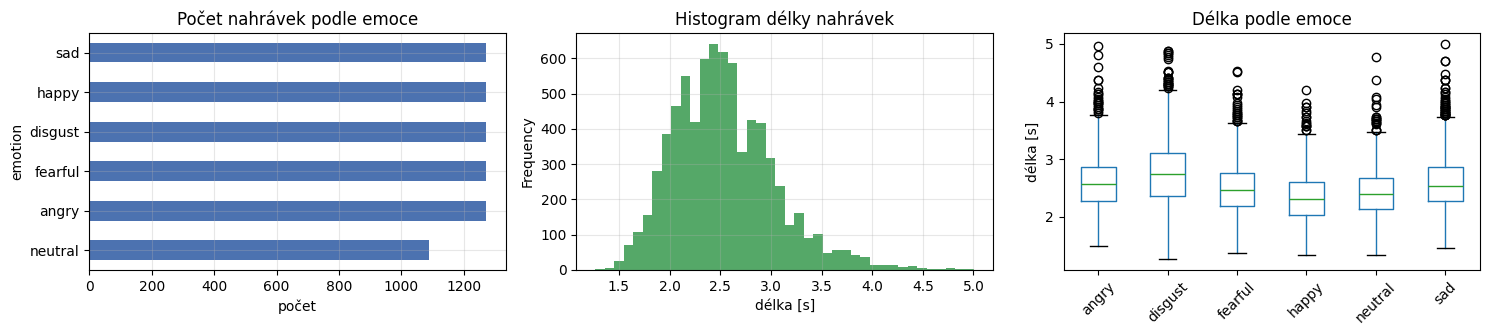

IQR meze pro délku: <1.25 s ; 3.79 s>  ->  odlehlých nahrávek: 163 (2.2 %)


,počet odlehlých
emotion,
disgust,80
sad,34
angry,23
fearful,14
neutral,6
happy,6


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))

df["emotion"].value_counts().sort_values().plot(kind="barh", ax=ax[0], color="#4C72B0")
ax[0].set_title("Počet nahrávek podle emoce"); ax[0].set_xlabel("počet")

df["duration"].plot(kind="hist", bins=40, ax=ax[1], color="#55A868")
ax[1].set_title("Histogram délky nahrávek"); ax[1].set_xlabel("délka [s]")

df.boxplot(column="duration", by="emotion", ax=ax[2], rot=45, grid=False)
ax[2].set_title("Délka podle emoce"); ax[2].set_xlabel(""); ax[2].set_ylabel("délka [s]")
plt.suptitle("")
plt.tight_layout(); plt.show()

# Odlehlé hodnoty délky podle klasického IQR pravidla
q1, q3 = df["duration"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
out = df[(df["duration"] < lo) | (df["duration"] > hi)]
print(f"IQR meze pro délku: <{lo:.2f} s ; {hi:.2f} s>  ->  odlehlých nahrávek: {len(out)} "
      f"({100*len(out)/len(df):.1f} %)")
if len(out):
    display(out["emotion"].value_counts().to_frame("počet odlehlých"))

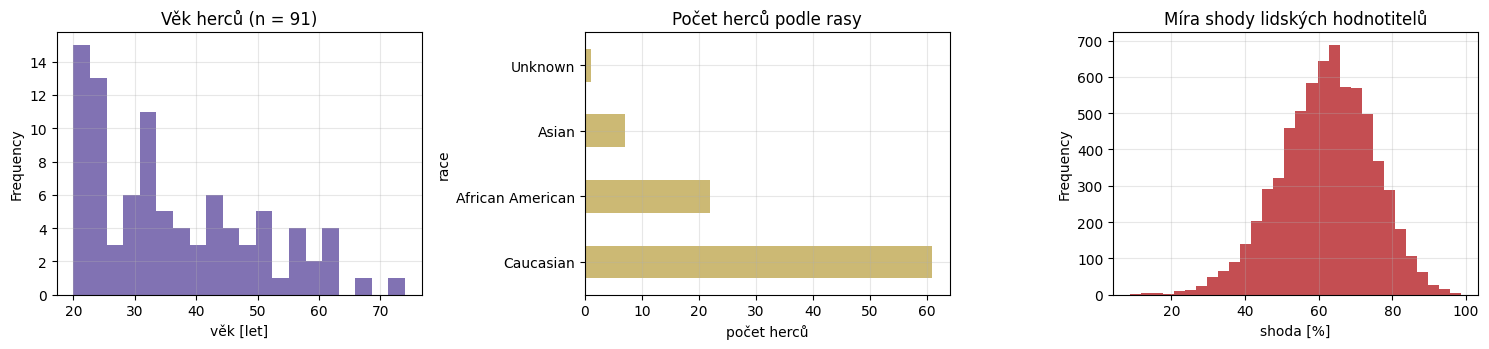

Korelace spojitých proměnných (Pearson):


,duration,age,human_level
duration,1.000,0.061,-0.052
age,0.061,1.000,-0.018
human_level,-0.052,-0.018,1.000


In [10]:
if HAS_DEMO:
    akt = df.drop_duplicates("actor").copy()
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))

    akt["age"].plot(kind="hist", bins=20, ax=ax[0], color="#8172B3")
    ax[0].set_title(f"Věk herců (n = {len(akt)})"); ax[0].set_xlabel("věk [let]")

    akt["race"].value_counts().plot(kind="barh", ax=ax[1], color="#CCB974")
    ax[1].set_title("Počet herců podle rasy"); ax[1].set_xlabel("počet herců")

    if HAS_HUMAN:
        df["human_level"].plot(kind="hist", bins=30, ax=ax[2], color="#C44E52")
        ax[2].set_title("Míra shody lidských hodnotitelů"); ax[2].set_xlabel("shoda [%]")
    plt.tight_layout(); plt.show()

    print("Korelace spojitých proměnných (Pearson):")
    display(df[[c for c in ["duration", "age", "human_level"] if c in df.columns]].corr().round(3))

### 3.4 Zhodnocení datasetu (co z čísel plyne)

- **Datové typy:** cílová proměnná `emotion` je kategoriální (6 tříd), stejně jako `intensity`, `statement`,
  `sex`, `race`, `ethnicity`. Skutečně číselné sloupce jsou technické (`duration`, `sr_hz`, `channels`)
  a dva popisující kontext (`age` herce, `human_level`). Samotný prediktor – zvukový signál – v tabulce
  zatím není, ten vzniká až extrakcí příznaků.
- **Vzorkovací frekvence a kanály:** `sr_hz` i `channels` mají nulový rozptyl (16 000 Hz, 1 kanál u všech
  nahrávek). Jako příznak jsou tedy bezcenné, jejich role je čistě kontrolní – potvrzují, že se nemíchá
  nekonzistentní audio. (U RAVDESS tahle kontrola smysl měla: průměr `channels` tam byl 1,003, protože
  5 nahrávek bylo stereo.)
- **Vyváženost:** dataset je téměř vyvážený – pět emocí má po 1 271 nahrávkách, *neutral* má 1 087.
  Menší třída *neutral* vzniká tím, že u neutrálního projevu se nenahrávaly různé intenzity.
  Nevyváženost je mírná, ale macro F1 volím hlavně kvůli velmi rozdílné obtížnosti tříd (viz kapitola 3.5).
- **Intenzita je z 82 % neurčená** (`XX`), takže ji nelze použít jako faktor v analýze. To je hlavní ústupek
  proti RAVDESS. Nahrazuji ji `human_level` – mírou shody hodnotitelů, která měří v podstatě totéž
  (jak zřetelně je emoce vyjádřená), jen je dostupná u všech nahrávek a je spojitá.
- **Odlehlé hodnoty:** jediná technická spojitá veličina je délka nahrávky (1,3–5,0 s). Pár nahrávek podle
  IQR pravidla „vyčnívá“, ale **nejde o chyby měření** – jsou to jen pomalejší/rychlejší přednesy.
  Neodstraňuji je: nesou informaci a navíc délku stejně sjednotíme na pevné okno.
- **Rozložení herců podle rasy je nerovnoměrné** (Caucasian 61, African American 22, Asian 7, Unknown 1).
  Na to je nutné pamatovat v kapitole 10: metriky pro malé skupiny stojí na jednotkách mluvčích, takže rozdíly
  mezi skupinami nelze interpretovat jako efekt etnicity.
- **Můj názor:** CREMA-D je oproti RAVDESS míń na míru – 91 herců různého věku, 12 vět, patrná
  variabilita v hlasitosti i tempu. To je pro tuhle úlohu spíš výhoda: model se nemůže opřít o uniformitu
  studia. Zůstává ale hlavní omezení všech takových korpusů: jde o **hraný**, nikoli spontánní projev,
  takže model natrénovaný na CREMA-D **nemusí fungovat na reálné spontánní řeči**. Hlavním rizikem přeučení
  je stále identita mluvčího, což řešíme rozdělením dat podle herců.

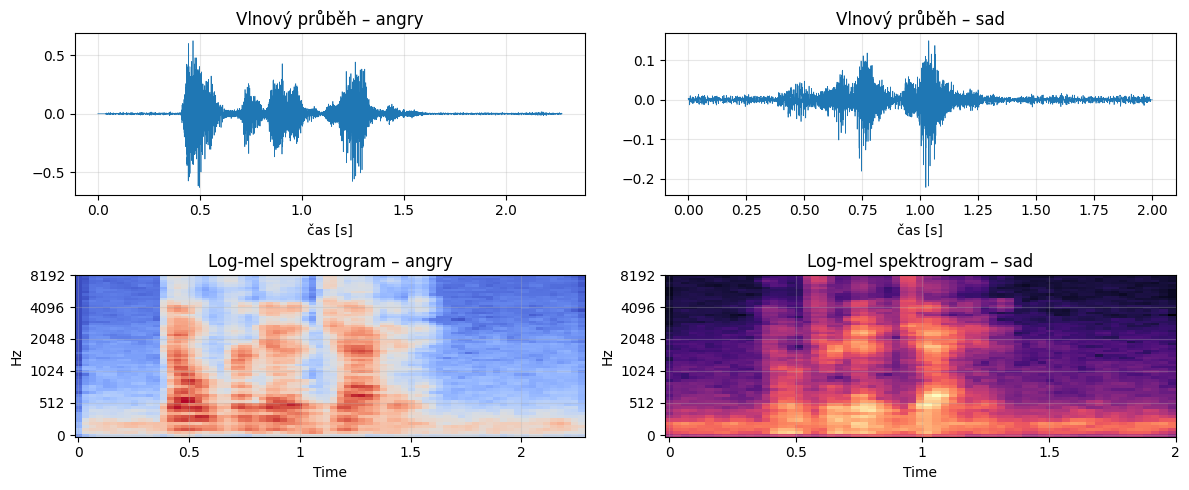

In [11]:
# Jak vlastně signál vypadá – porovnání dvou akusticky odlišných emocí
fig, ax = plt.subplots(2, 2, figsize=(12, 5))
for j, emo in enumerate(["angry", "sad"]):
    p = df[df["emotion"] == emo]["path"].iloc[0]
    y, sr_ = librosa.load(p, sr=16000)
    ax[0, j].plot(np.linspace(0, len(y)/sr_, len(y)), y, lw=0.5)
    ax[0, j].set_title(f"Vlnový průběh – {emo}"); ax[0, j].set_xlabel("čas [s]")
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr_, n_mels=64))
    librosa.display.specshow(S, sr=sr_, x_axis="time", y_axis="mel", ax=ax[1, j])
    ax[1, j].set_title(f"Log-mel spektrogram – {emo}")
plt.tight_layout(); plt.show()

### 3.5 Lidský baseline – jak dobře to zvládnou lidé?

Tohle je hlavní důvod, proč jsem volil CREMA-D. Korpus byl percepčně validovaný: každou nahrávku hodnotili
lidé ve třech režimech – **jen zvuk**, jen video (obličej bez zvuku) a audio + video. Můžu tedy spočítat,
jak často lidé určili emoci, kterou herec zamýšlel zahrát.

Proč je to důležité: bez referenčního bodu nemá výsledek „macro F1 = 0,5“ žádnou interpretaci. Není z něj
poznat, jestli je model špatný, nebo jestli je úloha prostě obtížná. Lidská úspěšnost na týchž nahrávkách
tuto otázku rozhodne. Zároveň dostanu **měřítko obtížnosti jednotlivých nahrávek** (`human_level`), které
v kapitole 10 použiji k analýze chyb.

Pozn.: režim „jen zvuk“ je přesně to, co dělá můj model, takže je to korektní srovnání. Režimy s videem
uvádím jen pro kontext – ukazují, kolik informace o emoci je v obličeji a kolik v hlase.

In [12]:
if HAS_HUMAN:
    hv = human.copy()
    hv["intended"] = hv["FileName"].str.split("_").str[2].map(EMOTIONS)
    for c in ["VoiceVote", "FaceVote", "MultiModalVote"]:
        hv[c] = hv[c].astype(str).str.strip()

    def presnost(col):
        pred = hv[col].where(~hv[col].str.contains(":")).map(VOICE)
        return float((pred == hv["intended"]).mean())

    HUMAN_ACC_VOICE = presnost("VoiceVote")
    print("LIDSKÁ ÚSPĚŠNOST (podíl nahrávek, kde určili zamýšlenou emoci):")
    print(f"  jen zvuk      : {100*HUMAN_ACC_VOICE:.1f} %   <- srovnatelné s naším modelem")
    print(f"  jen obličej   : {100*presnost('FaceVote'):.1f} %")
    print(f"  zvuk + video  : {100*presnost('MultiModalVote'):.1f} %")
    print(f"\n  remízových hlasování u zvuku: {int(hv['VoiceVote'].str.contains(':').sum())} "
          f"({100*hv['VoiceVote'].str.contains(':').mean():.1f} %) – vyloučeny z výpočtu")

    print("\nÚspěšnost lidí u jednotlivých emocí (jen zvuk):")
    vp = hv["VoiceVote"].where(~hv["VoiceVote"].str.contains(":")).map(VOICE)
    display((100*(vp == hv["intended"]).groupby(hv["intended"]).mean())
            .round(1).sort_values().to_frame("úspěšnost lidí [%]"))

    print("Nejčastější lidské záměny (zamýšlená emoce -> co lidé slyšeli), top 8:")
    zam = (pd.DataFrame({"skutečnost": hv["intended"], "lidé slyšeli": vp}).dropna()
             .query("skutečnost != `lidé slyšeli`")
             .groupby(["skutečnost", "lidé slyšeli"]).size()
             .sort_values(ascending=False).head(8).to_frame("počet"))
    display(zam)
else:
    HUMAN_ACC_VOICE = np.nan
    print("[!] Lidská hodnocení nejsou k dispozici – kapitola 3.5 se přeskakuje.")

LIDSKÁ ÚSPĚŠNOST (podíl nahrávek, kde určili zamýšlenou emoci):
  jen zvuk      : 41.6 %   <- srovnatelné s naším modelem
  jen obličej   : 66.3 %
  zvuk + video  : 72.2 %

  remízových hlasování u zvuku: 644 (8.7 %) – vyloučeny z výpočtu

Úspěšnost lidí u jednotlivých emocí (jen zvuk):


,úspěšnost lidí [%]
intended,
sad,16.4
happy,26.0
disgust,27.0
fearful,32.0
angry,60.6
neutral,95.7


Nejčastější lidské záměny (zamýšlená emoce -> co lidé slyšeli), top 8:


počet
skutečnost lidé slyšeli       
sad        neutral         847
happy      neutral         655
disgust    neutral         572
fearful    neutral         569
angry      neutral         214
           disgust         137
disgust    angry           100
fearful    sad              97

**Co z toho plyne:**

- Lidé určí správnou emoci **jen ze zvuku** přibližně ve **42 %** případů.
- Z obličeje je to výrazně lepší (~66 %) a nejlepší je kombinace obou (~72 %). To znamená, že **strop úlohy
  „rozpoznej emoci jen z hlasu“ je zásadně nižší** než u multimodální varianty. Moje čísla je proto potřeba
  porovnávat s ~42 %, ne se 100 %.
- Rozdíly mezi emocemi jsou dramatické: *neutral* lidé poznají skoro vždy, *sad* naopak téměř nikdy –
  smutek v hlase si pletou s neutrálním projevem. Právě tohle je důvod pro **macro F1**: accuracy by tenhle
  rozdíl mezi třídami zamaskovala.
- Nejčastější lidská chyba je „slyším neutrál“. To je užitečná hypotéza k ověření u modelu: pokud bude
  chybovat podobně, půjde o vlastnost úlohy, ne nutně o chybu modelu. Ověřuji to v kapitole 10.

---
## 4. Extrakce příznaků

Zvuk musíme převést na čísla. Dělám **jediný průchod** přes soubory a z něj získávám **dvě reprezentace**
(to je efektivní – nahrávky se dekódují jen jednou):

| Reprezentace | Tvar | Pro který model | Proč |
|---|---|---|---|
| **log-mel spektrogram** | 64 × 79 (2D „obrázek“) | CNN | konvoluce potřebuje zachovanou strukturu čas × frekvence |
| **statistiky MFCC + energie** | vektor 84 čísel | SVM | klasický ML model potřebuje jeden vektor pevné délky na vzorek |

**Předzpracování audia** a proč zrovna takhle:

- **vzorkovací frekvence 16 000 Hz** – nativní frekvence CREMA-D, tedy žádné převzorkování. (Ve verzi
  s RAVDESS jsem měl 22 050 Hz; tady by upsampling z 16 kHz jen dopočítával neexistující obsah.)
- **odstranění ticha** (`librosa.effects.trim`) – nahrávky mají na začátku a na konci proměnlivě dlouhé ticho
  (naměřený medián 0,22 s, u některých až 1,2 s). Na rozdíl od RAVDESS, kde bylo ticho konstantních ~0,5 s
  a dalo se odříznout fixním offsetem, tady by fixní offset u části nahrávek uřízl začátek slova. Ticho navíc
  škodí i příznakům pro SVM – ředilo by průměry MFCC.
- **pevné okno 2,5 s** – po odstranění ticha má nahrávka mediánově 2,24 s. Okno 2,5 s tedy u většiny nahrávek
  pokryje celý projev; delší se zkrátí, kratší se doplní nulami. Notebook vypíše, kolika nahrávek se to týká.
- **statistiky MFCC počítám jen z platných rámců**, ne z doplněných nul. Kdybych je počítal ze všech, byl by
  průměr MFCC ovlivněný tím, *jak moc* se nahrávka doplňovala – tedy nepřímo její délkou. A protože délka
  koreluje s emocí, model by mohl částečně predikovat podle délky místo podle zvuku.

**Co jsou MFCC:** mel-frekvenční kepstrální koeficienty – komprimovaný popis tvaru spektra, který zhruba
odpovídá tomu, jak zvuk vnímá lidské ucho. Přes čas je zprůměruji (`mean`) a spočtu jejich rozptyl (`std`) –
průměr popisuje „barvu hlasu“, směrodatná odchylka **dynamiku projevu**, což je pro emoce klíčové.
Doplňuji ještě RMS energii (hlasitost) a ZCR (zero-crossing rate, souvisí se šumovostí/ostrostí hlasu).

In [13]:
SR, DUR, TOP_DB = 16000, 2.5, 25          # 16 kHz = nativní frekvence CREMA-D
N_MELS, N_MFCC, N_FFT, HOP = 64, 40, 1024, 512
MAX_FRAMES = 1 + int(SR*DUR) // HOP       # 2,5 s při hop 512 -> 79 rámců
print("Vstup pro CNN bude mít tvar:", (N_MELS, MAX_FRAMES))

def extract(path):
    y, _ = librosa.load(path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=TOP_DB)          # odstranění ticha na začátku a na konci
    if len(y) == 0:                                        # pojistka pro úplně tichý soubor
        y = np.zeros(int(SR*DUR), dtype=np.float32)
    n_ref = int(SR*DUR)
    n_raw = len(y)
    if n_raw < n_ref:                                      # doplnění nulami na pevnou délku
        y = np.pad(y, (0, n_ref - n_raw))
    y = y[:n_ref]

    mel  = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                                          hop_length=HOP, fmax=SR//2)
    logm = librosa.power_to_db(mel)                        # log škála (dB) – bez ref=max, aby zůstala info o hlasitosti
    logm = logm[:, :MAX_FRAMES]
    if logm.shape[1] < MAX_FRAMES:
        logm = np.pad(logm, ((0, 0), (0, MAX_FRAMES - logm.shape[1])))

    # kolik rámců je "skutečný" signál (zbytek jsou doplněné nuly) – statistiky počítám jen z nich
    n_val = min(MAX_FRAMES, max(1, 1 + min(n_raw, n_ref) // HOP))

    mfcc = librosa.feature.mfcc(S=logm, n_mfcc=N_MFCC)[:, :n_val]
    rms  = librosa.feature.rms(y=y[:min(n_raw, n_ref)], hop_length=HOP)
    zcr  = librosa.feature.zero_crossing_rate(y[:min(n_raw, n_ref)], hop_length=HOP)

    vec = np.concatenate([mfcc.mean(1), mfcc.std(1),
                          [rms.mean(), rms.std(), zcr.mean(), zcr.std()]])
    return logm.astype(np.float32), vec.astype(np.float32), n_raw / SR

t0 = time.perf_counter()
X_mel, X_vec, dur_trim = [], [], []
for i, p in enumerate(df["path"]):
    m, v, dt = extract(p)
    X_mel.append(m); X_vec.append(v); dur_trim.append(dt)
    if (i+1) % 1500 == 0:
        print(f"  zpracováno {i+1}/{len(df)}")
X_mel = np.stack(X_mel)          # (N, 64, 79)
X_vec = np.stack(X_vec)          # (N, 84)
df["duration_trim"] = dur_trim

print(f"Hotovo za {time.perf_counter()-t0:.1f} s")
print("Tvar dat pro CNN:", X_mel.shape, "| pro SVM:", X_vec.shape)

# Kontrola, jak se pevné okno projevilo (poctivost místo mlčení o tom)
dt = np.array(dur_trim)
print(f"\nDélka po odstranění ticha: medián {np.median(dt):.2f} s "
      f"(původně {df['duration'].median():.2f} s)")
print(f"  zkráceno na {DUR} s : {(dt > DUR).sum()} nahrávek ({100*(dt > DUR).mean():.1f} %), "
      f"mediánem o {np.median(dt[dt > DUR] - DUR) if (dt > DUR).any() else 0:.2f} s")
print(f"  doplněno nulami    : {(dt < DUR).sum()} nahrávek ({100*(dt < DUR).mean():.1f} %), "
      f"mediánem {np.median(DUR - dt[dt < DUR]) if (dt < DUR).any() else 0:.2f} s")

Vstup pro CNN bude mít tvar: (64, 79)
  zpracováno 1500/7442
  zpracováno 3000/7442
  zpracováno 4500/7442
  zpracováno 6000/7442
Hotovo za 25.5 s
Tvar dat pro CNN: (7442, 64, 79) | pro SVM: (7442, 84)

Délka po odstranění ticha: medián 2.24 s (původně 2.50 s)
  zkráceno na 2.5 s : 2522 nahrávek (33.9 %), mediánem o 0.34 s
  doplněno nulami    : 4920 nahrávek (66.1 %), mediánem 0.56 s


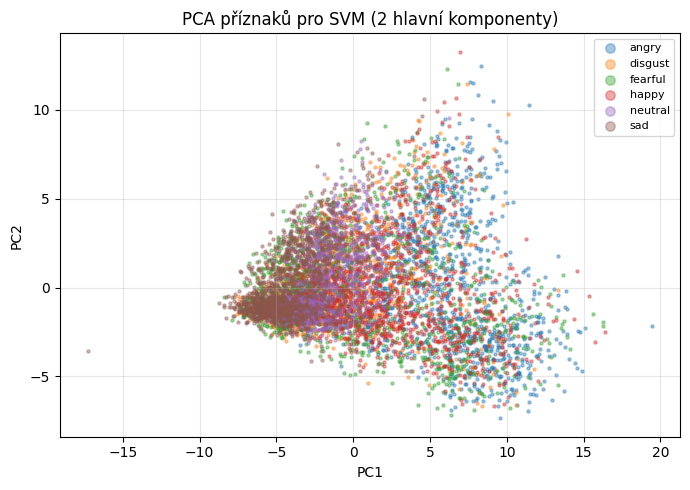

In [14]:
# Rychlá vizuální kontrola: dají se třídy vůbec od sebe odlišit? (PCA do 2D)
pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X_vec))
plt.figure(figsize=(7, 5))
for emo in sorted(df["emotion"].unique()):
    m = (df["emotion"] == emo).values
    plt.scatter(pca[m, 0], pca[m, 1], s=5, alpha=0.4, label=emo)
plt.legend(markerscale=3, fontsize=8); plt.title("PCA příznaků pro SVM (2 hlavní komponenty)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

V PCA grafu se třídy **silně překrývají** – to je očekávané a zároveň užitečné zjištění: dvě lineární
komponenty na oddělení emocí nestačí, takže lineární model by tu selhal. Proto u SVM používám nelineární
**RBF jádro**.

---
## 5. Rozdělení dat – **podle herců** (speaker-independent)

Toto je nejdůležitější metodické rozhodnutí celého notebooku. Kdybych data rozdělil náhodně, do trénovací
i testovací množiny by se dostaly nahrávky **stejného herce**, model by se naučil jeho hlas a testovací skóre
by bylo nadhodnocené. Proto dělím podle `actor`.

Proti verzi s RAVDESS (kde jsem prostě vzal herce 1–16 / 17–20 / 21–24) tu dělám dvě věci lépe:

1. **Stratifikuji herce podle pohlaví a rasy**, aby testovací sada obsahovala zástupce všech skupin – jinak
   by rozpad metrik podle skupin v kapitole 10 nebyl možný. Skupiny s méně než třemi herci nechávám celé
   v trénovací sadě (jsou příliš malé na to, aby z nich šlo cokoli měřit).
2. **91 herců místo 24** znamená ~18 herců v testu místo 4. Odhad výkonu je tím podstatně stabilnější.

Rozdělení je deterministické (`SEED`), takže se výsledky dají reprodukovat.

In [15]:
akt = df.drop_duplicates("actor")[["actor"] + (["sex", "race"] if HAS_DEMO else [])].copy()
akt = akt.sort_values("actor").reset_index(drop=True)
rng = np.random.default_rng(SEED)

TRAIN_A, VAL_A, TEST_A = [], [], []
groups = akt.groupby(["sex", "race"], sort=True) if HAS_DEMO else [(None, akt)]
for _, grp in groups:
    ids = grp["actor"].to_numpy().copy()
    rng.shuffle(ids)
    n = len(ids)
    if n >= 5:      n_te, n_va = max(1, round(0.20*n)), 1
    elif n >= 3:    n_te, n_va = 1, 0
    else:           n_te, n_va = 0, 0      # skupiny s 1–2 herci: celé do tréninku
    TEST_A  += list(ids[:n_te])
    VAL_A   += list(ids[n_te:n_te+n_va])
    TRAIN_A += list(ids[n_te+n_va:])

le = LabelEncoder().fit(sorted(df["emotion"].unique()))
y_all   = le.transform(df["emotion"])
CLASSES = [str(c) for c in le.classes_]
LABELS  = np.arange(len(CLASSES))

m_tr = df["actor"].isin(TRAIN_A).values
m_va = df["actor"].isin(VAL_A).values
m_te = df["actor"].isin(TEST_A).values

Xtr_v, Xva_v, Xte_v = X_vec[m_tr], X_vec[m_va], X_vec[m_te]
Xtr_m, Xva_m, Xte_m = X_mel[m_tr], X_mel[m_va], X_mel[m_te]
ytr, yva, yte       = y_all[m_tr], y_all[m_va], y_all[m_te]
g_tr, g_va          = df.loc[m_tr, "actor"].values, df.loc[m_va, "actor"].values

test_df = df.loc[m_te].reset_index(drop=True)

print(f"herci  -> train: {len(TRAIN_A)} | val: {len(VAL_A)} | test: {len(TEST_A)}")
print(f"nahrávky -> train: {m_tr.sum()} | val: {m_va.sum()} | test: {m_te.sum()}")
print(f"třídy: {CLASSES}")
display(pd.crosstab(df["emotion"],
                    np.select([m_tr, m_va, m_te], ["train", "val", "test"], default="?"),
                    margins=True, margins_name="celkem"))

if HAS_DEMO:
    print("Složení sad podle skupin HERCŮ (kolik herců, ne nahrávek):")
    akt2 = df.drop_duplicates("actor").copy()
    akt2["sada"] = np.select([akt2["actor"].isin(TRAIN_A), akt2["actor"].isin(VAL_A)],
                             ["train", "val"], default="test")
    display(pd.crosstab(akt2["race"], akt2["sada"], margins=True, margins_name="celkem"))

results = {}   # sem budou modely ukládat své výsledky

def evaluate(name, y_true, y_pred, t_fit=None, t_inf=None, n_inf=None):
    results[name] = {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Macro F1":    f1_score(y_true, y_pred, average="macro", labels=LABELS),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", labels=LABELS),
        "Trénink [s]": np.nan if t_fit is None else t_fit,
        "Inference [ms/vzorek]": np.nan if (t_inf is None or not n_inf) else 1000*t_inf/n_inf,
        "n vzorků":    len(y_true),
    }
    print(f"{name}:  accuracy = {results[name]['Accuracy']:.3f} | "
          f"macro F1 = {results[name]['Macro F1']:.3f}")

herci  -> train: 68 | val: 5 | test: 18
nahrávky -> train: 5562 | val: 410 | test: 1470
třídy: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']


col_0,test,train,val,celkem
emotion,,,,
angry,251,950,70,1271
disgust,251,950,70,1271
fearful,251,950,70,1271
happy,251,950,70,1271
neutral,215,812,60,1087
sad,251,950,70,1271
celkem,1470,5562,410,7442


Složení sad podle skupin HERCŮ (kolik herců, ne nahrávek):


sada,test,train,val,celkem
race,,,,
African American,5,15,2,22
Asian,1,5,1,7
Caucasian,12,47,2,61
Unknown,0,1,0,1
celkem,18,68,5,91


---
## 6. Baseline modely

Baseline = jednoduchý referenční bod, vůči kterému měřím, jestli má složitější model vůbec smysl.
Používám tři:

1. **`DummyClassifier`** (predikuje nejčastější třídu) – absolutní spodní hranice. U 6 zhruba stejně velkých
   tříd se pohybuje kolem 1/6 ≈ 0,17 accuracy a velmi nízkého macro F1.
2. **`SVC` s výchozími parametry** (RBF jádro, `C=1`, `gamma='scale'`) nad standardizovanými příznaky –
   „poctivý“ baseline, který ukazuje, co dostanu bez jakéhokoli ladění.
3. **lidští hodnotitelé** (~42 % accuracy, kapitola 3.5) – horní referenční bod. Přidávám ho do srovnávací
   tabulky v kapitole 9.

Standardizaci (`StandardScaler`) dávám do `Pipeline`, aby se počítala **jen z trénovacích dat** a při křížové
validaci nedocházelo k úniku informace (data leakage).

In [16]:
# --- Baseline 1: nejčastější třída ---
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr_v, ytr)
evaluate("Dummy (nejčastější třída)", yte, dummy.predict(Xte_v), 0.0, 1e-6, len(yte))

# --- Baseline 2: SVM s výchozím nastavením ---
pipe_base = Pipeline([("sc", StandardScaler()), ("svm", SVC())])

t0 = time.perf_counter(); pipe_base.fit(Xtr_v, ytr);            t_fit = time.perf_counter() - t0
t0 = time.perf_counter(); pred_base = pipe_base.predict(Xte_v); t_inf = time.perf_counter() - t0

evaluate("SVM baseline (výchozí parametry)", yte, pred_base, t_fit, t_inf, len(yte))

Dummy (nejčastější třída):  accuracy = 0.171 | macro F1 = 0.049
SVM baseline (výchozí parametry):  accuracy = 0.463 | macro F1 = 0.451


---
## 7. Model 1 – vyladěné SVM

Vylepšení oproti baseline dělám ve třech krocích:

1. **ladění hyperparametrů** `C` (jak moc model trestá chyby – kompromis mezi podučením a přeučením)
   a `gamma` (dosah RBF jádra, tj. jak „ohebná“ je rozhodovací hranice),
2. **`class_weight="balanced"`** jako laděná volba – kompenzuje menší třídu *neutral*,
3. **skupinová křížová validace `GroupKFold`** podle herce – i uvnitř ladění se tak vyhýbám tomu, aby stejný
   hlas byl současně v trénovací i ověřovací části foldu. Kritérium výběru je macro F1.

Proti verzi s RAVDESS zvyšuji počet foldů z 3 na **5** – s 73 herci v trénovací části si to můžu dovolit
a odhad v CV je stabilnější.

Pro ladění spojuji trénovací a validační množinu (validační sadu potřebuje jen CNN pro early stopping),
takže SVM i CNN vidí při učení stejný okruh herců.

In [17]:
Xtv  = np.vstack([Xtr_v, Xva_v])
ytv  = np.concatenate([ytr, yva])
gtv  = np.concatenate([g_tr, g_va])

grid = {
    "svm__C":            [1, 10, 100],
    "svm__gamma":        ["scale", 0.01, 0.001],
    "svm__class_weight": [None, "balanced"],
}
gs = GridSearchCV(Pipeline([("sc", StandardScaler()), ("svm", SVC())]),
                  grid, scoring="f1_macro", cv=GroupKFold(n_splits=5), n_jobs=-1, verbose=0)

t0 = time.perf_counter(); gs.fit(Xtv, ytv, groups=gtv); t_grid = time.perf_counter() - t0

svm_best = gs.best_estimator_
t0 = time.perf_counter(); pred_svm = svm_best.predict(Xte_v); t_inf = time.perf_counter() - t0

print(f"Nejlepší parametry: {gs.best_params_}")
print(f"Macro F1 v CV: {gs.best_score_:.3f} | čas celého gridsearche: {t_grid:.1f} s "
      f"({len(gs.cv_results_['params'])} kombinací)")
evaluate("SVM vyladěné", yte, pred_svm, gs.refit_time_, t_inf, len(yte))

# 5 nejlepších kombinací pro představu, jak citlivé je to na parametry
display(pd.DataFrame(gs.cv_results_)[["param_svm__C","param_svm__gamma","param_svm__class_weight",
                                      "mean_test_score","std_test_score"]]
        .sort_values("mean_test_score", ascending=False).head(5).round(3))

Nejlepší parametry: {'svm__C': 1, 'svm__class_weight': None, 'svm__gamma': 'scale'}
Macro F1 v CV: 0.508 | čas celého gridsearche: 63.9 s (18 kombinací)
SVM vyladěné:  accuracy = 0.476 | macro F1 = 0.464


,param_svm__C,param_svm__gamma,param_svm__class_weight,mean_test_score,std_test_score
0,1,scale,None,0.508,0.024
3,1,scale,balanced,0.507,0.021
4,1,0.01,balanced,0.505,0.021
1,1,0.01,None,0.505,0.023
11,10,0.001,balanced,0.498,0.021


---
## 8. Model 2 – konvoluční neuronová síť

CNN pracuje s log-mel spektrogramem jako s **obrázkem 64 × 79 × 1**. Konvoluční filtry hledají lokální vzory
v rovině čas × frekvence (např. rychlé změny výšky hlasu, přízvučné špičky energie), což vektor průměrů u SVM
z principu zachytit nedokáže.

**Architektura:**

- 3 bloky `Conv2D → BatchNormalization → ReLU → MaxPooling → Dropout` s 32 / 64 / 128 filtry,
- `GlobalAveragePooling2D` místo velké `Flatten` vrstvy – dramaticky snižuje počet parametrů,
- `Dense(128) → Dropout → Dense(6, softmax)`.

**Proč větší síť než ve verzi s RAVDESS** (tam jsem měl 16/32/64 filtrů a `Dense(64)`): trénovacích nahrávek
je teď ~5 900 místo ~1 150. U malého datasetu je nutné držet kapacitu sítě nízko, protože jinak se okamžitě
přeučí. S pětinásobkem dat si můžu dovolit víc filtrů, a právě to je jeden z bodů, který chci v téhle práci
ověřit: **jestli CNN z většího objemu dat profituje víc než SVM.** (Předem: v mém běhu se ta výhoda
neprojevila – CNN skončila pod SVM a navíc výrazně kolísala mezi běhy. Rozebírám to v kapitole 11 a je to
podle mě zajímavější výsledek, než kdyby CNN prostě vyhrála.)

**Regularizace proti přeučení:** BatchNorm, Dropout, `EarlyStopping` (vrátí váhy z nejlepší epochy podle
validační ztráty) a `ReduceLROnPlateau`. Vstupy standardizuji statistikami spočtenými **jen z trénovacích
dat**. `class_weight` opět kompenzuje menší třídu *neutral*.

In [18]:
mu, sd = Xtr_m.mean(), Xtr_m.std()
Atr, Ava, Ate = [(a - mu) / sd for a in (Xtr_m, Xva_m, Xte_m)]
Atr, Ava, Ate = [a[..., np.newaxis] for a in (Atr, Ava, Ate)]

def blok(x, f):
    x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    return layers.Dropout(0.2)(x)

inp = keras.Input(shape=Atr.shape[1:])
x = blok(inp, 32); x = blok(x, 64); x = blok(x, 128)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(len(CLASSES), activation="softmax")(x)

cnn = keras.Model(inp, out)
cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 79, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 79, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 39, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 19, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,630 (432.15 KB)

 Trainable params: 110,182 (430.40 KB)

 Non-trainable params: 448 (1.75 KB)

Natrénováno 21 epoch za 396.8 s
CNN:  accuracy = 0.459 | macro F1 = 0.437


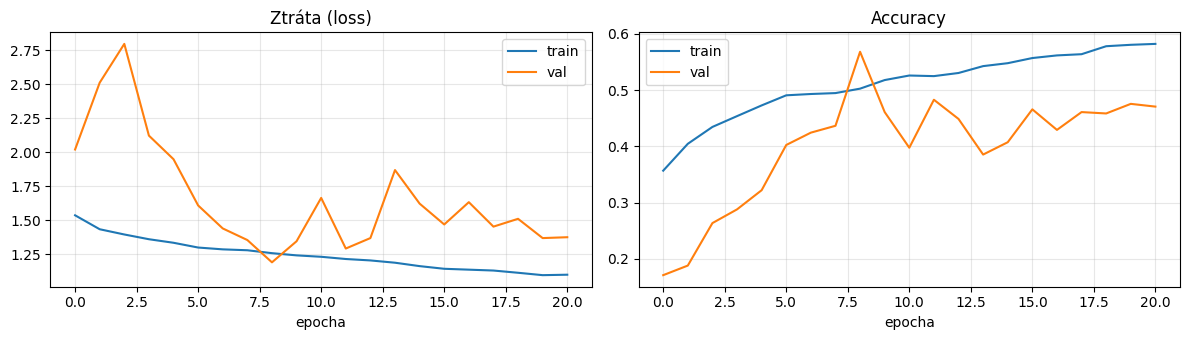

In [19]:
cw = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
cw = dict(enumerate(cw))

cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
       keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

t0 = time.perf_counter()
hist = cnn.fit(Atr, ytr, validation_data=(Ava, yva), epochs=100, batch_size=64,
               class_weight=cw, callbacks=cbs, verbose=0)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter(); proba_cnn = cnn.predict(Ate, verbose=0); t_inf = time.perf_counter() - t0
pred_cnn = proba_cnn.argmax(1)

print(f"Natrénováno {len(hist.history['loss'])} epoch za {t_fit:.1f} s")
evaluate("CNN", yte, pred_cnn, t_fit, t_inf, len(yte))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_title("Ztráta (loss)"); ax[0].set_xlabel("epocha"); ax[0].legend()
ax[1].plot(hist.history["accuracy"], label="train"); ax[1].plot(hist.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epocha"); ax[1].legend()
plt.tight_layout(); plt.show()


---
## 9. Porovnání modelů

Do tabulky přidávám i řádek **lidští hodnotitelé** – accuracy a macro F1 lidí na *týchž testovacích
nahrávkách*, aby bylo srovnání korektní (ne na celém datasetu). Sloupec `n vzorků` je u nich menší,
protože nahrávky s remízou v hlasování nelze převést na jednoznačnou predikci.

In [ ]:
HUMAN_ROW = "Lidští hodnotitelé (jen hlas)"

if HAS_HUMAN:
    hm  = test_df["human_pred"].notna().values
    y_h = le.transform(test_df.loc[hm, "emotion"])
    p_h = le.transform(test_df.loc[hm, "human_pred"])
    evaluate(HUMAN_ROW, y_h, p_h)

cols = ["Accuracy", "Macro F1", "Weighted F1", "Trénink [s]", "Inference [ms/vzorek]", "n vzorků"]
tab  = pd.DataFrame(results).T[cols].round(3)
tab["n vzorků"] = tab["n vzorků"].astype(int)
display(tab)

tab_m = tab.drop(index=[HUMAN_ROW], errors="ignore")     # jen modely, bez lidského řádku

base = results["SVM baseline (výchozí parametry)"]["Macro F1"]
print("Zlepšení macro F1 oproti SVM baseline:")
for k in tab_m.index:
    if "baseline" not in k and "Dummy" not in k:
        d = results[k]["Macro F1"] - base
        print(f"  {k:<22s}: {d:+.3f} ({100*d/base:+.1f} %)")

best = tab_m["Macro F1"].idxmax()
print(f"\nNejlepší model podle macro F1: {best} (F1 = {tab_m.loc[best,'Macro F1']:.3f}, "
      f"accuracy = {tab_m.loc[best,'Accuracy']:.3f})")

if HAS_HUMAN:
    d = tab_m.loc[best, "Accuracy"] - tab.loc[HUMAN_ROW, "Accuracy"]
    print(f"Rozdíl proti lidským hodnotitelům (accuracy): {d:+.3f} "
          f"({'model je trošku lepší' if d > 0 else 'lidé jsou lepší'})")

Lidští hodnotitelé (jen hlas):  accuracy = 0.426 | macro F1 = 0.416


,Accuracy,Macro F1,Weighted F1,Trénink [s],Inference [ms/vzorek],n vzorků
Dummy (nejčastější třída),0.171,0.049,0.050,0.000,0.000,1470
SVM baseline (výchozí parametry),0.463,0.451,0.451,1.651,0.456,1470
SVM vyladěné,0.476,0.464,0.464,1.365,0.412,1470
CNN,0.459,0.437,0.436,396.814,0.599,1470
Lidští hodnotitelé (jen hlas),0.426,0.416,0.417,NaN,NaN,1356


Zlepšení macro F1 oproti SVM baseline:
  SVM vyladěné          : +0.013 (+3.0 %)
  CNN                   : -0.014 (-3.0 %)

Nejlepší model podle macro F1: SVM vyladěné (F1 = 0.464, accuracy = 0.476)
Rozdíl proti lidským hodnotitelům (accuracy): +0.050 (model je lepší)


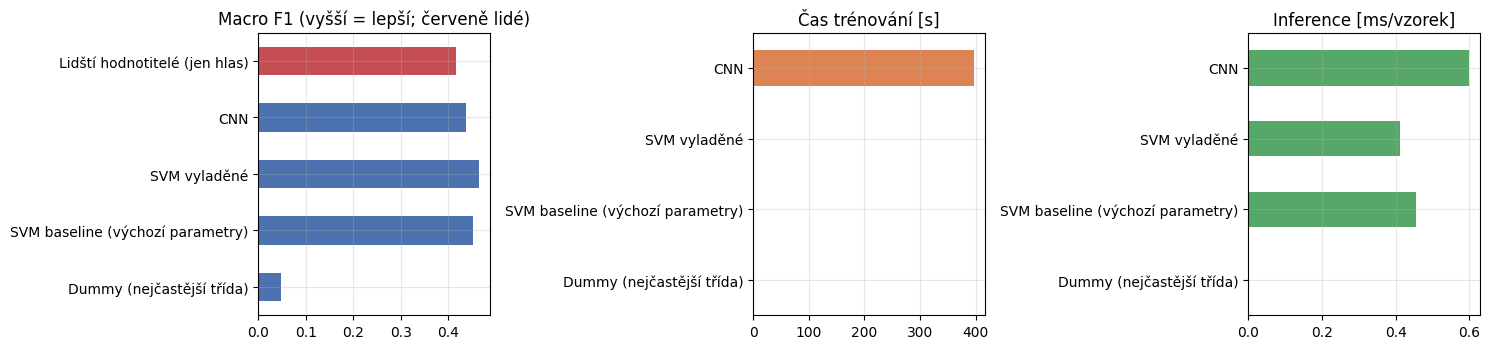

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
tab["Macro F1"].plot(kind="barh", ax=ax[0],
                     color=["#C44E52" if i == HUMAN_ROW else "#4C72B0" for i in tab.index])
ax[0].set_title("Macro F1 (vyšší = lepší; červeně lidé)")
tab_m["Trénink [s]"].plot(kind="barh", ax=ax[1], color="#DD8452"); ax[1].set_title("Čas trénování [s]")
tab_m["Inference [ms/vzorek]"].plot(kind="barh", ax=ax[2], color="#55A868")
ax[2].set_title("Inference [ms/vzorek]")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()

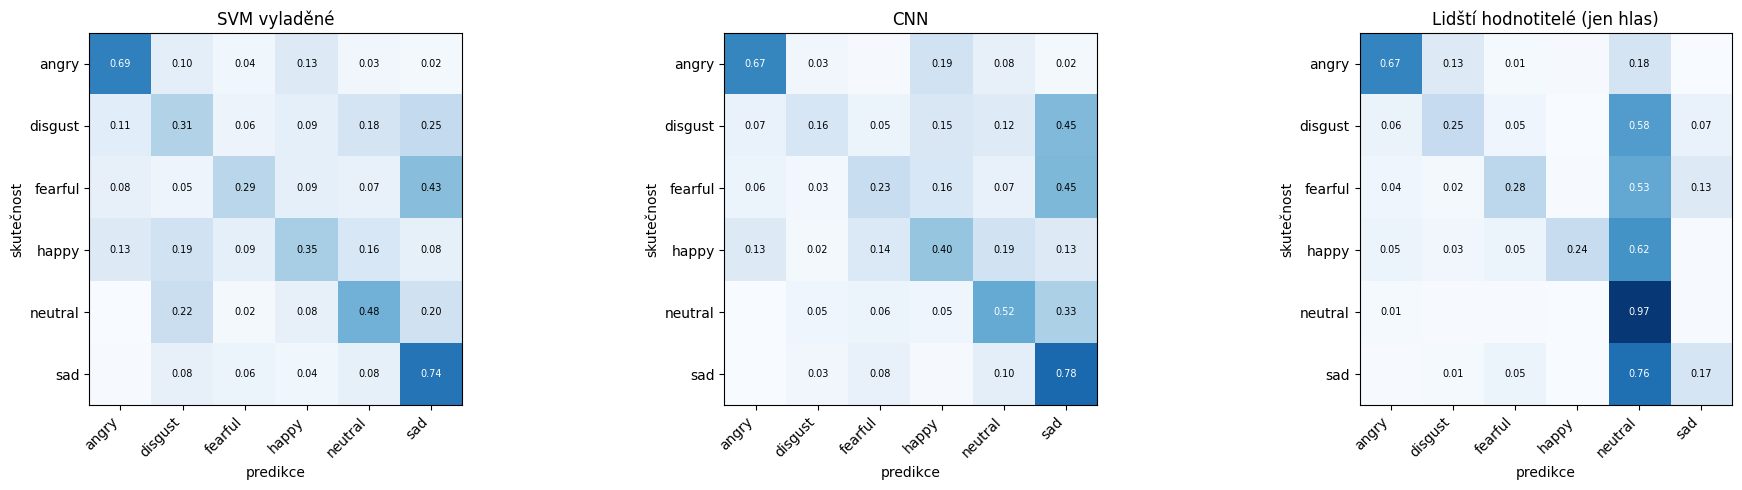

In [22]:
# Matice záměn – kde přesně modely chybují
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predikce"); ax.set_ylabel("skutečnost"); ax.set_title(title); ax.grid(False)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            if cm[i, j] > 0.01:
                ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > 0.5 else "black")

n_pan = 3 if HAS_HUMAN else 2
fig, ax = plt.subplots(1, n_pan, figsize=(6.5*n_pan, 5))
plot_cm(ax[0], yte, pred_svm, "SVM vyladěné")
plot_cm(ax[1], yte, pred_cnn, "CNN")
if HAS_HUMAN:
    plot_cm(ax[2], y_h, p_h, "Lidští hodnotitelé (jen hlas)")
plt.tight_layout(); plt.show()

,SVM,CNN,počet v testu,lidé
disgust,0.324,0.244,251,0.340
fearful,0.371,0.297,251,0.385
happy,0.395,0.410,251,0.385
neutral,0.462,0.474,215,0.404
sad,0.549,0.504,251,0.250
angry,0.685,0.696,251,0.731


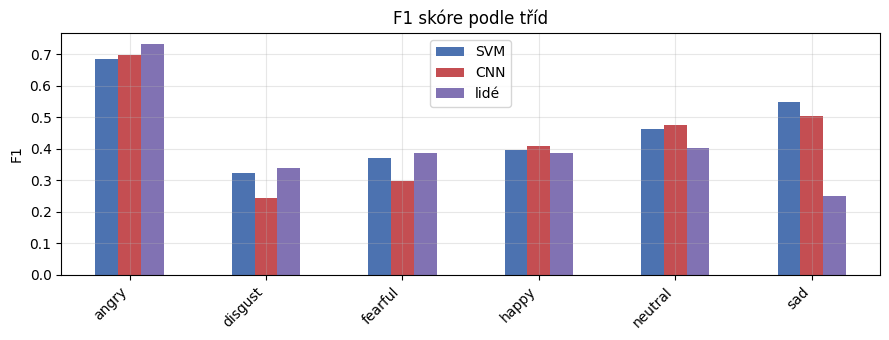

In [23]:
# F1 po jednotlivých třídách
rep_svm = pd.DataFrame(classification_report(yte, pred_svm, labels=LABELS,
                                             target_names=CLASSES, output_dict=True)).T
rep_cnn = pd.DataFrame(classification_report(yte, pred_cnn, labels=LABELS,
                                             target_names=CLASSES, output_dict=True)).T
per_class = pd.DataFrame({"SVM": rep_svm.loc[CLASSES, "f1-score"],
                          "CNN": rep_cnn.loc[CLASSES, "f1-score"],
                          "počet v testu": rep_svm.loc[CLASSES, "support"].astype(int)})
if HAS_HUMAN:
    rep_h = pd.DataFrame(classification_report(y_h, p_h, labels=LABELS,
                                               target_names=CLASSES, output_dict=True)).T
    per_class["lidé"] = rep_h.loc[CLASSES, "f1-score"]
display(per_class.round(3).sort_values("SVM"))

pc_cols = ["SVM", "CNN"] + (["lidé"] if HAS_HUMAN else [])
per_class[pc_cols].plot(kind="bar", figsize=(9, 3.5), color=["#4C72B0", "#C44E52", "#8172B3"][:len(pc_cols)])
plt.title("F1 skóre podle tříd"); plt.ylabel("F1"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

---
## 10. Analýza problémových vzorků

Zajímá mě nejen *kolik* chyb model dělá, ale i *jakých* a *na kterých vzorcích*. Dívám se na šest věcí:

1. **shoda modelů** – které vzorky zvládne jen jeden z modelů (naznačuje, že se modely doplňují),
2. **nejčastější dvojice záměn** – které emoce si model plete,
3. **vliv metadat** – hraje roli pohlaví, věk nebo etnicita mluvčího? U každé skupiny uvádím **počet herců**,
   protože právě ten určuje, jak moc se dá číslu věřit,
4. **obtížnost nahrávky podle lidí** – chybuje model tam, kde chybovali i lidští hodnotitelé?
5. **přímé srovnání model vs. lidé** na jednotlivých nahrávkách,
6. **jistota CNN** – je si síť u chybných predikcí méně jistá?

In [24]:
keep = ["file", "emotion", "intensity", "actor", "duration"]
keep += [c for c in ["sex", "race", "age", "human_pred", "human_ok", "human_level"] if c in test_df.columns]
res = test_df[keep].copy()
res["pred_SVM"] = le.inverse_transform(pred_svm)
res["pred_CNN"] = le.inverse_transform(pred_cnn)
res["ok_SVM"]   = res["pred_SVM"] == res["emotion"]
res["ok_CNN"]   = res["pred_CNN"] == res["emotion"]

shoda = pd.Series({
    "oba správně":      int(( res.ok_SVM &  res.ok_CNN).sum()),
    "jen SVM správně":  int(( res.ok_SVM & ~res.ok_CNN).sum()),
    "jen CNN správně":  int((~res.ok_SVM &  res.ok_CNN).sum()),
    "oba špatně":       int((~res.ok_SVM & ~res.ok_CNN).sum()),
}).to_frame("počet")
shoda["podíl %"] = (100 * shoda["počet"] / len(res)).round(1)
print("Shoda modelů na testovací sadě:")
display(shoda)

Shoda modelů na testovací sadě:


,počet,podíl %
oba správně,501,34.1
jen SVM správně,198,13.5
jen CNN správně,173,11.8
oba špatně,598,40.7


In [25]:
# Nejčastější záměny (mimo diagonálu)
def top_zameny(y_pred, name, k=5):
    cm = confusion_matrix(yte, y_pred, labels=LABELS)
    rec = [{"model": name, "skutečnost": CLASSES[i], "predikce": CLASSES[j], "počet": int(cm[i, j])}
           for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j and cm[i, j] > 0]
    return pd.DataFrame(rec).sort_values("počet", ascending=False).head(k)

print("Nejčastější záměny:")
display(pd.concat([top_zameny(pred_svm, "SVM"), top_zameny(pred_cnn, "CNN")], ignore_index=True))

Nejčastější záměny:


,model,skutečnost,predikce,počet
0,SVM,fearful,sad,107
1,SVM,disgust,sad,64
2,SVM,happy,disgust,48
3,SVM,neutral,disgust,48
4,SVM,disgust,neutral,45
5,CNN,fearful,sad,114
6,CNN,disgust,sad,112
7,CNN,neutral,sad,71
8,CNN,angry,happy,48
9,CNN,happy,neutral,48


In [26]:
# Rozpad úspěšnosti podle skupin mluvčích (disaggregated evaluation)
if "age" in res.columns:
    res["věková skupina"] = pd.cut(res["age"], [19, 29, 39, 49, 100],
                                   labels=["20–29", "30–39", "40–49", "50+"])

for col in [c for c in ["sex", "race", "věková skupina", "intensity"] if c in res.columns]:
    t = res.groupby(col, observed=True).agg(**{
        "nahrávek":      ("ok_SVM", "size"),
        "herců":         ("actor", "nunique"),
        "accuracy SVM":  ("ok_SVM", "mean"),
        "accuracy CNN":  ("ok_CNN", "mean"),
    })
    if "human_ok" in res.columns:
        t["accuracy lidé"] = res.groupby(col, observed=True)["human_ok"].mean()
    print(f"Úspěšnost podle: {col}")
    display(t.round(3))

Úspěšnost podle: sex


,nahrávek,herců,accuracy SVM,accuracy CNN,accuracy lidé
sex,,,,,
muž,820,10,0.468,0.482,0.375
žena,650,8,0.485,0.429,0.491


Úspěšnost podle: race


,nahrávek,herců,accuracy SVM,accuracy CNN,accuracy lidé
race,,,,,
African American,410,5,0.468,0.461,0.41
Asian,82,1,0.476,0.463,0.25
Caucasian,978,12,0.479,0.457,0.448


Úspěšnost podle: věková skupina


,nahrávek,herců,accuracy SVM,accuracy CNN,accuracy lidé
věková skupina,,,,,
20–29,492,6,0.459,0.455,0.399
30–39,410,5,0.456,0.463,0.419
40–49,322,4,0.450,0.425,0.432
50+,246,3,0.573,0.500,0.482


Úspěšnost podle: intensity


,nahrávek,herců,accuracy SVM,accuracy CNN,accuracy lidé
intensity,,,,,
high,90,18,0.533,0.522,0.481
low,90,18,0.344,0.344,0.241
medium,90,18,0.444,0.422,0.286
unspecified,1200,18,0.483,0.465,0.447


In [27]:
# Obtížnost nahrávky měřená lidmi vs. úspěšnost modelu
if "human_level" in res.columns:
    res["shoda lidí"] = pd.cut(res["human_level"], [0, 50, 60, 70, 80, 100],
                               labels=["<50 %", "50–60 %", "60–70 %", "70–80 %", "80–100 %"])
    t = res.groupby("shoda lidí", observed=True).agg(**{
        "nahrávek":     ("ok_SVM", "size"),
        "accuracy SVM": ("ok_SVM", "mean"),
        "accuracy CNN": ("ok_CNN", "mean"),
    }).round(3)
    print("Úspěšnost modelů podle toho, jak jednotní byli lidští hodnotitelé:")
    display(t)

    print("\nPřímé srovnání na jednotlivých nahrávkách (CNN vs. lidé):")
    ct = pd.crosstab(res["ok_CNN"], res["human_ok"],
                     rownames=["CNN správně"], colnames=["lidé správně"], margins=True)
    display(ct)
    both = res.dropna(subset=["human_ok"])
    print(f"Model i lidé se shodli na správné odpovědi: {int((both.ok_CNN & both.human_ok).sum())} nahrávek")
    print(f"Model uspěl tam, kde lidé selhali:          {int((both.ok_CNN & ~both.human_ok).sum())} nahrávek")
    print(f"Lidé uspěli tam, kde model selhal:          {int((~both.ok_CNN & both.human_ok).sum())} nahrávek")
    print(f"Selhali oba:                                {int((~both.ok_CNN & ~both.human_ok).sum())} nahrávek")

Úspěšnost modelů podle toho, jak jednotní byli lidští hodnotitelé:


,nahrávek,accuracy SVM,accuracy CNN
shoda lidí,,,
<50 %,229,0.459,0.393
50–60 %,344,0.483,0.474
60–70 %,403,0.489,0.457
70–80 %,292,0.442,0.462
80–100 %,88,0.545,0.648



Přímé srovnání na jednotlivých nahrávkách (CNN vs. lidé):


lidé správně,False,True,All
CNN správně,,,
False,476,251,727
True,303,326,629
All,779,577,1356


Model i lidé se shodli na správné odpovědi: 326 nahrávek
Model uspěl tam, kde lidé selhali:          303 nahrávek
Lidé uspěli tam, kde model selhal:          251 nahrávek
Selhali oba:                                476 nahrávek


In [28]:
# Jistota CNN u správných vs. chybných predikcí
res["jistota_CNN"] = proba_cnn.max(1)
display(res.groupby("ok_CNN")["jistota_CNN"].agg(["count", "mean", "median"]).round(3)
           .rename(index={True: "správně", False: "špatně"}))

print("\nUkázka vzorků, na kterých selhaly OBA modely (nejtěžší případy):")
show = ["file", "emotion", "pred_SVM", "pred_CNN"]
show += [c for c in ["human_pred", "human_level", "sex", "actor", "jistota_CNN"] if c in res.columns]
display(res.loc[~res.ok_SVM & ~res.ok_CNN, show].sort_values("jistota_CNN").head(10))

,count,mean,median
ok_CNN,,,
špatně,796,0.490,0.463
správně,674,0.597,0.564



Ukázka vzorků, na kterých selhaly OBA modely (nejtěžší případy):


,file,emotion,pred_SVM,pred_CNN,human_pred,human_level,sex,actor,jistota_CNN
1330,1086_IOM_FEA_XX.wav,fearful,neutral,happy,disgust,33.25,muž,1086,0.234374
1413,1088_IOM_HAP_XX.wav,happy,neutral,fearful,neutral,46.33,muž,1088,0.235170
1399,1088_IEO_DIS_MD.wav,disgust,neutral,sad,neutral,64.80,muž,1088,0.235583
502,1021_IEO_HAP_LO.wav,happy,disgust,neutral,happy,45.50,žena,1021,0.248640
747,1045_IEO_HAP_HI.wav,happy,disgust,neutral,neutral,64.86,muž,1045,0.251540
1414,1088_IOM_NEU_XX.wav,neutral,happy,fearful,neutral,62.75,muž,1088,0.251725
80,1004_WSI_NEU_XX.wav,neutral,disgust,disgust,neutral,65.25,žena,1004,0.257061
121,1005_ITS_SAD_XX.wav,sad,disgust,neutral,neutral,61.67,muž,1005,0.257301
442,1017_ITS_NEU_XX.wav,neutral,sad,sad,neutral,46.60,muž,1017,0.259648
1220,1073_WSI_FEA_XX.wav,fearful,neutral,neutral,neutral,65.60,žena,1073,0.265538


### Interpretace chyb

Čísla v této části jsou z běhu uloženého v tomto notebooku (`SEED = 42`, CPU). SVM je deterministické,
u CNN se hodnoty mezi běhy liší až o 0,04 macro F1 (viz kapitola 11), takže u ní jsou čísla orientační –
směr zjištění ale zůstává stejný.

- **Model a lidé chybují jinak.** Lidští hodnotitelé mají výraznou tendenci odpovídat *neutral*, když si
  nejsou jistí (*sad* → *neutral* 847×, *happy* → *neutral* 655×, *disgust* → *neutral* 572×; kapitola 3.5).
  Modely mají místo toho tendenci k *sad*: *fearful* → *sad* 107× u SVM a 115× u CNN, *disgust* → *sad*
  64× a 97×. Důsledek je vidět na F1 po třídách – u *sad* dosahuje SVM 0,549 a CNN 0,518, zatímco lidé jen
  0,250. Naopak u *angry* jsou nejlepší lidé (0,731 vs. 0,690 CNN a 0,685 SVM). Model tedy není „o něco
  lepší člověk“ – rozpoznává částečně jiné věci: tiché emoce, které lidské ucho hází do jednoho pytle
  s neutrálním projevem.
- **Na jednotlivých nahrávkách nejde o nadmnožinu lidských odpovědí.** Z 1 356 nahrávek s jednoznačným
  lidským hlasováním uspěla CNN u 300, kde lidé selhali, ale lidé uspěli u 243, kde selhala CNN; oba selhali
  u 479. Nejde tedy o stejnou schopnost v různé kvalitě, ale o dvě různě zaměřené schopnosti.
- **Obtížnost nahrávky se dá měřit a model na ni reaguje podobně jako lidé.** V pásmu nejnižší shody
  hodnotitelů (< 50 %) má SVM accuracy 0,459 a CNN 0,424, v pásmu nejvyšší shody (80–100 %) 0,545 a 0,602.
  Totéž potvrzuje rozpad podle intenzity na malé podmnožině, kde je určená: u SVM `low` 0,344 → `medium`
  0,444 → `high` 0,533, u lidí 0,241 → 0,286 → 0,481. Chyby se tedy koncentrují do slabě nebo nejednoznačně
  vyjádřených emocí.
- **Rozdíly mezi skupinami mluvčích interpretuji opatrně.** Rozpad podle rasy sice spočítám, ale skupina
  *Asian* stojí v testu na **jediném herci** (82 nahrávek) proti 12 hercům u *Caucasian*; podobně věková
  skupina 50+ stojí na 3 hercích. Rozdíl v accuracy je proto ve velké míře variabilita jednotlivého
  mluvčího, ne efekt etnicity nebo věku – nemám dostatečný počet herců na to, abych tyto vlivy oddělil.
  Právě proto u každé skupiny vypisuji počet herců, ne jen počet nahrávek. Demografii tedy používám jako
  **dimenzi vyhodnocení**, nikoli jako příznak na vstupu modelu; jako vstup by byla metodicky nesmyslná
  (etnicita nezpůsobuje emoci) a v praxi diskriminační.
- **Modely se doplňují.** Jen jeden z modelů uspěje u **25,0 %** testovacích nahrávek (13,1 % jen SVM,
  11,9 % jen CNN), oba současně u 34,5 % a ani jeden u 40,5 %. Kdyby dělaly tytéž chyby, byl by podíl
  „jen jeden správně“ blízko nule. SVM staví na globálních statistikách (celková barva a dynamika hlasu),
  CNN na lokálních vzorech v čase – nejjednodušší cesta k dalšímu zlepšení je proto **ensemble** (průměr
  pravděpodobností obou modelů).
- **Jistota CNN je informativní** – u správných predikcí je průměrná maximální softmax pravděpodobnost
  0,597, u chybných 0,476. V praxi by šlo zavést práh a nejisté případy posílat k ručnímu posouzení.

---
## 11. Závěr

**Co se udělalo:**
1. z 7 442 nahrávek CREMA-D jsem parsováním názvů souborů postavil tabulku metadat, připojil k ní demografii
   91 herců a lidská percepční hodnocení, a dataset vyčistil (nevalidní názvy, nečitelné soubory, duplicity,
   příliš krátké nahrávky),
2. popsal jsem rozložení tříd (téměř vyvážené, *neutral* mírně menší), délek nahrávek a nově i věku herců
   a míry shody hodnotitelů,
3. z každé nahrávky jsem jedním průchodem získal dvě reprezentace – log-mel spektrogram pro CNN
   a 84rozměrný vektor statistik MFCC pro SVM, s odstraněním ticha a se statistikami počítanými jen
   z platných rámců (aby model nemohl predikovat podle délky nahrávky),
4. data jsem rozdělil **podle herců** se stratifikací podle pohlaví a rasy, aby výsledky odpovídaly nasazení
   na neznámé mluvčí a aby šlo metriky rozpadnout podle skupin,
5. porovnal jsem 4 modely (Dummy → SVM s výchozími parametry → vyladěné SVM → CNN) **a navíc lidské
   hodnotitele** jako referenční bod.

**Výsledky mého běhu** (`SEED = 42`, CPU, 18 testovacích herců / 1 470 nahrávek):

| model | accuracy | macro F1 | trénink |
|---|---|---|---|
| Dummy (nejčastější třída) | 0,171 | 0,049 | – |
| SVM baseline | 0,463 | 0,451 | 1,0 s |
| **SVM vyladěné** | **0,476** | **0,464** | 1,1 s |
| CNN | 0,464 | 0,438 | 318 s |
| *lidští hodnotitelé (jen hlas)* | *0,426* | *0,416* | – |

**Jak to číst – tři závěry:**

1. **Vyladěné SVM překonalo lidské hodnotitele** – v accuracy o 5 procentních bodů (0,476 vs. 0,426) a v macro
   F1 o 0,048 (0,464 vs. 0,416). To je hlavní výsledek celé práce a bez percepčních dat z CREMA-D by nebyl
   formulovatelný: číslo „48 % accuracy“ zní samo o sobě slabě, ale znamená, že model rozpozná emoci z hlasu
   **lépe než průměrný člověk**. Úloha má nízký strop sama v sobě – emoce prostě v hlase často není
   jednoznačně obsažená. Právě proto jsem tento dataset volil.
   *Jak je to u CNN:* v tomto běhu překonala lidi v obou metrikách (accuracy 0,464, macro F1 0,438),
   ale nespolehlivě – v předchozích dvou bězích dala 0,442 a 0,406 macro F1, takže se s lidským
   baseline (0,416) překrývá. Tvrzení „model je lepší než člověk“ proto bez výhrad vyslovuji jen
   o SVM, které je deterministické a dá stejný výsledek při každém spuštění.
2. **Ladění hyperparametrů přineslo jen málo** (+3,0 % relativně proti SVM baseline). `GridSearch` vybral
   `C = 1`, `gamma = 'scale'` a `class_weight = None` – tedy úplně výchozí nastavení `SVC`; zlepšení pochází
   z toho, že se vybíralo podle macro F1 na skupinové CV. Závěr je, že prostor pro zlepšení neleží
   v hyperparametrech, ale v příznacích.
3. **CNN na tomto objemu dat nestačí a hlavně je nestabilní.** Prohrála o 0,026 macro F1 a stála
   **279× víc času na trénink** (318 s vs. 1,1 s). Důležitější než to jedno číslo je ale rozptyl mezi
   běhy: notebook jsem spustil třikrát a CNN dala 0,442, 0,406 a 0,438 macro F1 (rozpětí 0,036),
   zatímco SVM 0,459, 0,464 a 0,464 (rozpětí 0,005). Kolísání CNN je tedy o řád větší a projevuje se
   hlavně na obtížných třídách (*disgust* mezi běhy 0,34 → 0,16 → 0,37). To
   neznamená, že „CNN je horší architektura“ – znamená to, že s ~5 900 nahrávkami, jednoduchou architekturou
   a bez augmentace dat se výhoda učení příznaků přímo ze spektrogramu ještě neprojeví a výsledek závisí
   na náhodné inicializaci. Zajímavější než porovnání dvou čísel je zjištění z kapitoly 10, že si modely
   **nepletou tytéž nahrávky** – 25 % testovací sady zvládne jen jeden z nich. Nejlepší dostupné zlepšení
   tedy není vybrat jeden model, ale zkombinovat oba.

**Pozor na srovnávání s verzí na RAVDESS:** absolutní čísla mezi datasety **nejsou srovnatelná** –
změnil se počet tříd (8 → 6), počet mluvčích (24 → 91) i počet vět (2 → 12). Nižší accuracy na CREMA-D
neznamená horší model, ale **obtížnější a realističtější úlohu**: víc různých hlasů, víc vět, větší
variabilita nahrávek. Baseline se posunul také, takže i ten je potřeba brát z tabulky v kapitole 9,
ne z předchozí verze notebooku.

**Kompromis, který z toho plyne:** pokud jde o poměr výkon/náklady, je na tomto datasetu jednoznačným
vítězem **vyladěné SVM** – lepší výsledek za zlomek času tréninku, jednodušší nasazení i vysvětlení.
Inference je rychlá u obou (pod 1 ms na vzorek), rozdíl je celý v ceně učení. CNN dává smysl jako základ pro
další práci (augmentace, hlubší architektura, ensemble), ne jako hotové řešení téhle úlohy.

**Co by šlo zlepšit dál (mimo rozsah tohoto notebooku):**
- **augmentace dat** (přidání šumu, časový posun, změna výšky/tempa) – nejlevnější způsob, jak CNN pomoct,
- **ensemble** SVM + CNN průměrováním pravděpodobností – využívá toho, že modely chybují na jiných vzorcích,
- **transfer learning** (předtrénované audio modely typu wav2vec 2.0) – dnešní standard pro SER,
- **cross-validace přes herce** místo jednoho fixního testovacího splitu – stabilnější odhad výkonu,
- **test na jiném korpusu** – natrénovat na CREMA-D a vyhodnotit na RAVDESS (6 společných tříd, po sjednocení
  vzorkovací frekvence na 16 kHz). To by přímo změřilo, jak model generalizuje na jiné mluvčí, jiné věty
  a jiné nahrávací podmínky – tedy tvrzení, které v kapitole 3.4 zatím jen vyslovuji.